# Implémentation de I-JEPA

*Cédric GAUTHERET*

Ce notebook reproduit l'architecture et la méthodologie de l'article **I-JEPA** (Image Joint-Embedding Predictive Architecture) sur le dataset Tiny ImageNet (64x64).

[Self-Supervised Learning from Images with a Joint-Embedding Predictive Architecture](https://arxiv.org/abs/2301.08243)

[Tiny ImageNet](https://www.kaggle.com/datasets/akash2sharma/tiny-imagenet)

**Contexte et motivation :**

I-JEPA (Image-based Joint-Embedding Predictive Architecture) est une méthode d'apprentissage auto-supervisé (SSL) proposée par Meta AI. Contrairement aux approches basées sur l'invariance (comme SimCLR, BYOL, DINO) qui reposent sur des augmentations de données artificielles et intenses (recadrage, flou, etc.), I-JEPA s'en affranchit. Ces anciennes méthodes introduisent des biais inductifs forts qui détruisent la compréhension spatiale locale.

D'autre part, les méthodes génératives comme MAE (Masked Autoencoders) cherchent à reconstruire les pixels exacts manquants. L'espace des pixels étant dense et redondant, MAE gaspille énormément de calculs pour des détails de haute fréquence inutiles sémantiquement.

I-JEPA propose donc une troisième voie : prédire l'information manquante directement dans un espace de représentation abstrait, sans générer l'image.

## Imports

In [ ]:
import os
import copy

import matplotlib.pyplot as plt
import kagglehub
from PIL import Image
import numpy as np
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.nn.functional as F

/home/cedric/miniforge3/envs/my_ml312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

On fait le choix d'utiliser TinyImageNet, une version allégée d'ImageNet car on a une capacité de stockage et de traitement limitée.

**Tiny ImageNet** est une version miniature du célèbre dataset **ImageNet**. Alors qu'ImageNet (dans sa version standard) regroupe plus d'un million d'images haute résolution réparties en 1 000 classes pour un poids d'environ 150 Go, Tiny ImageNet se limite à **100 000 images d'entraînement** divisées en **200 classes**, le tout pesant à peine 240 Mo. La différence majeure réside dans la taille des images : elles sont ici figées en **$64 \times 64$ pixels**, contre des résolutions variables et bien plus élevées pour l'original. Ce format ultra-compressé rend le stockage et l'entraînement accessibles sur un simple GPU grand public.

In [2]:
# Téléchargement de Tiny ImageNet via kagglehub
print("Téléchargement du dataset Tiny ImageNet...")
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")
print("Chemin du dataset :", path)

# Définition des chemins vers les dossiers d'entraînement et de validation
train_dir = os.path.join(path, "tiny-imagenet-200", "train")
val_dir = os.path.join(path, "tiny-imagenet-200", "val")

Téléchargement du dataset Tiny ImageNet...
Chemin du dataset : /home/cedric/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1


### Exploration des données

Visualisation de quelques échantillons bruts du dataset.

Les images de TinyImageNet ont une résolution de 64x64 contrairement au dataset ImageNet utilisé dans l'article qui ont des images de taille 224x224 correspondant aux entrées des ViT, on aura donc des ajustements à faire.

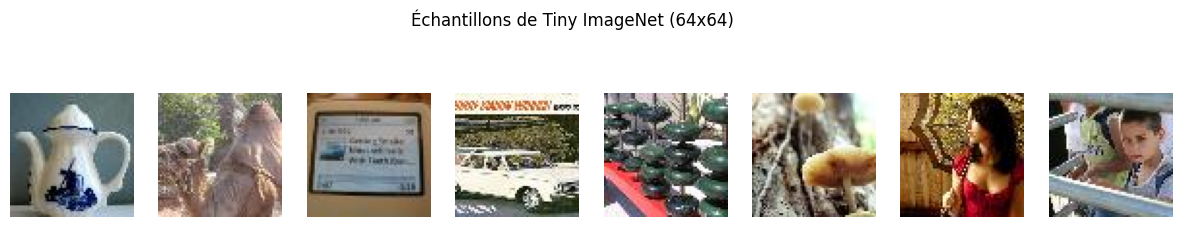

In [3]:
raw_transform = transforms.Compose([
    transforms.ToTensor()
])

raw_dataset = ImageFolder(train_dir, transform=raw_transform)
raw_loader = DataLoader(raw_dataset, batch_size=8, shuffle=True)

# Visualisation
def show_images(imgs, title=""):
    fig, axes = plt.subplots(1, len(imgs), figsize=(15, 3))
    for i, img in enumerate(imgs):
        axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].axis('off')
    plt.suptitle(title)
    plt.show()

try:
    dataiter = iter(raw_loader)
    images, labels = next(dataiter)
    show_images(images, "Échantillons de Tiny ImageNet (64x64)")
except StopIteration:
    print("Erreur : Impossible de charger les images. Vérifiez le chemin du dataset.")

### Pre-processing (Augmentations)
L'article I-JEPA insiste sur l'utilisation d'augmentations géométriques minimalistes, en évitant les augmentations destructrices de couleurs pour forcer le modèle à apprendre de la structure spatiale. Nous utilisons `RandomResizedCrop` et `RandomHorizontalFlip`.

In [ ]:
# L'article original utilise une échelle de recadrage (scale) entre (0.3, 1.0)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(64, scale=(0.3, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# Pour la visualisation du pre-processing, on crée une copie sans la normalisation
vis_transform = transforms.Compose([
    transforms.RandomResizedCrop(64, scale=(0.3, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_dir, transform=train_transform)

# Définition du DataLoader pour l'entraînement
# On choisit un batch_size de 64
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=False)

On créé le jeu de validation différemment car les classes n'ont pas été réparties dossier par dossier comme c'est le cas pour l'entrainement.

In [ ]:
class TinyImageNetValDataset(torch.utils.data.Dataset):
    def __init__(self, val_dir, train_dataset, transform=None):
        self.val_dir = val_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Charger les annotations
        anno_path = os.path.join(val_dir, 'val_annotations.txt')
        with open(anno_path, 'r') as f:
            for line in f:
                parts = line.split('\t')
                img_name = parts[0]
                class_id = parts[1]
                self.images.append(os.path.join(val_dir, 'images', img_name))
                self.labels.append(train_dataset.class_to_idx[class_id])
                
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]
    
val_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = TinyImageNetValDataset(val_dir, train_dataset, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

train_counts = Counter(train_dataset.labels)
# On récupère les IDs des 10 classes les plus fréquentes (si égalité, prend les premières)
top_10_classes = [item[0] for item in train_counts.most_common(10)]
top_10_labels = [train_dataset.classes[c] for c in top_10_classes]

print(f"Les 10 classes ciblées : {top_10_classes}")

Les 10 classes ciblées : [107, 139, 140, 69, 161, 147, 73, 145, 39, 158]


On en profite pour récupérer les 10 classes les plus représentées, on testera/validera notre modèle sur celle ci, c'est plus simple car 200 classes c'est impossible à visualiser et pour se donner une chance d'avoir des résultats correct, on s'assure de prendre des classes qui soient suffisamment représentées car le jeu de données est plutot mal réparti

### Visualisation

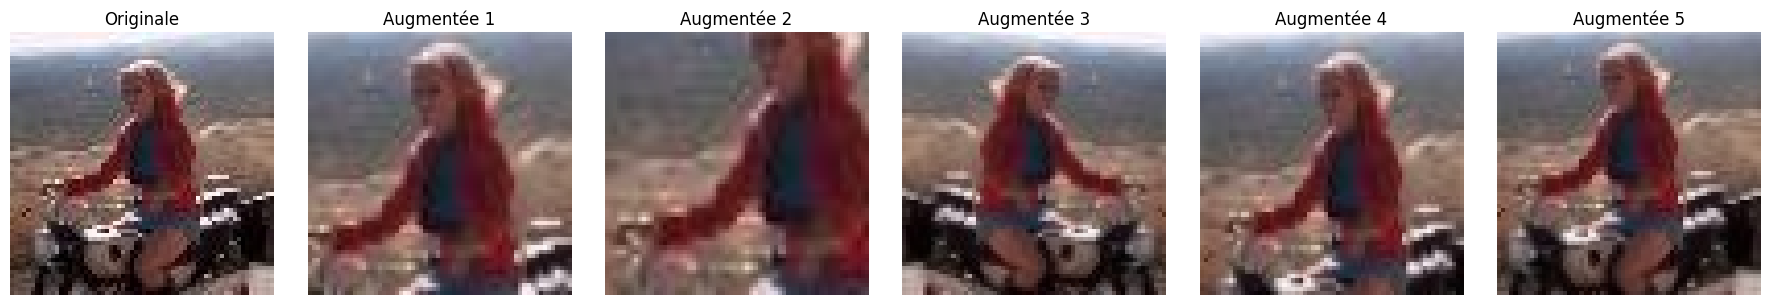

In [5]:
try:
    first_class = os.listdir(train_dir)[0]
    img_folder = os.path.join(train_dir, first_class, 'images')
    sample_img_path = os.path.join(img_folder, os.listdir(img_folder)[0])

    sample_img = Image.open(sample_img_path).convert('RGB')

    # exemple sur 5 transformations
    augmented_imgs = [vis_transform(sample_img) for _ in range(5)]

    # Affichage : image originale + 5 variations augmentées
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))

    axes[0].imshow(sample_img)
    axes[0].set_title("Originale")
    axes[0].axis('off')

    for i in range(5):
        axes[i+1].imshow(augmented_imgs[i].permute(1, 2, 0).numpy())
        axes[i+1].set_title(f"Augmentée {i+1}")
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erreur lors de la visualisation : {e}")

## Architecture du Modèle (ViT-Tiny)

L'architecture de I-JEPA repose sur trois composants principaux, tous basés sur des Vision Transformers (ViT) :
1. **Encodeur de Contexte ($E_\theta$)** : extrait une représentation riche de la partie visible de l'image.
2. **Encodeur Cible ($E_{\bar{\theta}}$)** : calcule les représentations cibles pour les zones masquées.
3. **Prédicteur ($P_\phi$)** : fait le pont sémantique pour déduire la cible à partir du contexte.

### Choix d'implémentation

| Paramètre | Article Original (ViT-L/16) | Notre Choix (ViT-T/4) | Justification |
| :--- | :--- | :--- | :--- |
| **Résolution** | 224x224 | 64x64 | Adaptation à Tiny ImageNet et limitation de calcul. |
| **Taille Patch** | 16x16 | 4x4 | Pour une image 64x64, un patch 4x4 donne 16x16=256 patchs, ce qui est proche des 196 patchs (14x14) de l'original. |
| **Embed Dim** | 1024 (Large) | 192 (Tiny) | Réduction drastique du nombre de paramètres pour l'entraînement sur GPU modeste. |
| **Profondeur** | 24 | 12 | Standard pour ViT-Tiny. |
| **Prédicteur** | ViT-B ou Narrower | ViT-T (Depth 6) | Le prédicteur doit être plus léger que l'encodeur pour éviter qu'il ne fasse tout le travail lourd. |

### 1. Embeddings Positionnels (Sin-Cos 2D)

Conformément à l'article, nous utilisons des **embeddings positionnels sin-cos 2D fixes**. Contrairement aux embeddings appris, ceux-ci permettent au modèle de mieux généraliser aux relations spatiales et sont particulièrement efficaces dans les architectures prédictives comme I-JEPA et MAE.

In [ ]:
def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    """
    Génère un embedding positionnel 2D sin-cos fixe.
    Le grid_size correspond au nombre de patchs par côté (ex: 16 pour 64x64 avec patch 4x4).
    """
    grid_h = torch.arange(grid_size, dtype=torch.float32)
    grid_w = torch.arange(grid_size, dtype=torch.float32)
    grid = torch.meshgrid(grid_w, grid_h, indexing='ij')
    grid = torch.stack(grid, dim=0)
    grid = grid.reshape([2, 1, grid_size, grid_size])
    
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = torch.cat([torch.zeros([1, embed_dim]), pos_embed], dim=0)
    return pos_embed

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0
    # Utilisation de la moitié des dimensions pour H et l'autre pour W
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])
    emb = torch.cat([emb_h, emb_w], dim=1)
    return emb

def get_1d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0
    omega = torch.arange(embed_dim // 2, dtype=torch.float32)
    omega /= embed_dim / 2.
    omega = 1. / (10000**omega)

    grid = grid.flatten()
    out = torch.einsum('m,d->md', grid, omega)
    emb_sin = torch.sin(out)
    emb_cos = torch.cos(out)
    emb = torch.cat([emb_sin, emb_cos], dim=1)
    return emb

### 2. Mécanisme d'Attention et Blocs Transformer

Nous implémentons ici les composants de base du Vision Transformer (ViT). L'attention multi-têtes permet au modèle de capturer des dépendances à longue distance entre les patchs, ce qui est crucial pour reconstruire sémantiquement une zone manquante à partir du contexte global.

In [7]:
class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        # Calcul simultané de Query, Key et Value pour l'efficacité
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        # Redimensionnement pour séparer les têtes d'attention
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Produit scalaire des Query et Key pour obtenir les scores d'attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Application des scores aux Values et retour à la dimension d'origine
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [8]:
class Block(nn.Module):
    """
    Un bloc Transformer standard : Norm -> Attention -> Residual -> Norm -> MLP -> Residual.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        # MLP avec une activation non linéaire (GELU) et un dropout pour régulariser
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(), # Activation GELU comme dans BERT et ViT
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(drop)
        )

    def forward(self, x):
        # Application de l'attention avec une connexion résiduelle pour faciliter l'entraînement des réseaux profonds
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

### 3. Vision Transformer (ViT-Tiny)

Cette classe implémente le backbone ViT. Pour I-JEPA, l'encodeur de contexte ne reçoit qu'un sous-ensemble de patchs. Nous avons donc ajouté un paramètre `patch_indices` à la méthode `forward` pour permettre cette sélection.

L'encodeur de contexte et l'encodeur cible partagent la même architecture de Vision Transformer. 

L'encodeur de contexte ne traite que les patches visibles de l'image (le contexte), y ajoute les embeddings de position et sort une séquence de vecteurs latents. L'encodeur cible traite les patches des zones à prédire (cibles). 

Pour éviter l'effondrement des représentations (representation collapse)
- un problème courant où le réseau finit par sortir une constante
- l'encodeur cible n'est pas optimisé par descente de gradient. 

Ses poids sont mis à jour dynamiquement via une **Moyenne Glissante Exponentielle (EMA - Exponential Moving Average)** des poids de l'encodeur de contexte. Cela garantit des cibles stables et riches.

In [9]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=64, patch_size=4, in_chans=3, embed_dim=192, depth=12, num_heads=3, mlp_ratio=4.):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        # Projection linéaire des patchs d'image en vecteurs (embeddings)
        self.patch_embed = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        # Embeddings positionnels non appris (fixes)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim), requires_grad=False)

        # Blocs Transformer
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, qkv_bias=True) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        
        self.initialize_weights()

    def initialize_weights(self):
        # Initialisation du grille sin-cos
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.num_patches**.5), cls_token=False)
        self.pos_embed.data.copy_(pos_embed.float().unsqueeze(0))

    def forward(self, x, patch_indices=None):
        # Transformation de l'image en patchs projetés
        x = self.patch_embed(x).flatten(2).transpose(1, 2) + self.pos_embed
        
        # Sélection des patchs visibles (spécifique à l'encodeur de contexte I-JEPA)
        if patch_indices is not None:
            # Utilisation de gather pour extraire les patchs sans broadcasting
            # patch_indices est [B, N_vis]
            idx = patch_indices.unsqueeze(-1).expand(-1, -1, x.size(-1))
            x = torch.gather(x, 1, idx)
            
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return x

### 4. Le Prédicteur I-JEPA

C'est ici que réside la spécificité de I-JEPA : le prédicteur travaille dans l'**espace latent**. Il prend les représentations issues de l'encodeur de contexte et tente de prédire les représentations des blocs cibles. Il utilise des `mask_tokens` auxquels on ajoute les embeddings positionnels des zones à prédire.

Le prédicteur agit comme un pont sémantique. Il prend les représentations du contexte et y concatène des tokens de masque intégrant l'encodage positionnel correspondant aux zones cibles à prédire.

Le prédicteur est volontairement un réseau ViT plus étroit et moins profond (plus léger) que les encodeurs. Cette asymétrie architecturale crée un goulot d'étranglement de l'information, forçant l'encodeur de contexte à structurer son espace latent de manière extrêmement cohérente.

In [10]:
class IJEPAPredictor(nn.Module):
    """
    Le prédicteur est un ViT plus léger chargé de faire la prédiction dans l'espace des embeddings.
    """
    def __init__(self, embed_dim=192, predictor_embed_dim=192, depth=6, num_heads=3, num_patches=256):
        super().__init__()
        self.predictor_embed = nn.Linear(embed_dim, predictor_embed_dim)
        # Le mask_token représente un patch manquant que l'on veut prédire
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, predictor_embed_dim), requires_grad=False)
        
        # Profondeur réduite (6 au lieu de 12) pour un prédicteur plus léger
        self.blocks = nn.ModuleList([
            Block(predictor_embed_dim, num_heads, qkv_bias=True) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(predictor_embed_dim)
        
        self.initialize_weights()

    def initialize_weights(self):
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], int(self.pos_embed.shape[1]**.5), cls_token=False)
        self.pos_embed.data.copy_(pos_embed.float().unsqueeze(0))
        torch.nn.init.normal_(self.mask_token, std=.02)

    def forward(self, x, context_indices, target_indices):
        # x: Représentations latentes du contexte [B, N_vis, C]
        
        x = self.predictor_embed(x)
        B = x.shape[0]
        
        # Ré-injection optionnelle de la position du contexte pour aider le Predictor
        all_pos = self.pos_embed.repeat(B, 1, 1)
        # Utilisation de gather pour extraire les positions sans broadcasting
        ctx_pos_idx = context_indices.unsqueeze(-1).expand(-1, -1, all_pos.size(-1))
        context_pos = torch.gather(all_pos, 1, ctx_pos_idx)
        x = x + context_pos
        
        # Création des tokens pour les patchs cibles (mask_token + position cible)
        target_tokens = self.mask_token.repeat(B, target_indices.shape[1], 1)
        tgt_pos_idx = target_indices.unsqueeze(-1).expand(-1, -1, all_pos.size(-1))
        target_pos = torch.gather(all_pos, 1, tgt_pos_idx)
        target_tokens = target_tokens + target_pos
        
        # Séquence complète pour le Predictor : [Contexte, Cibles Masquées]
        x = torch.cat([x, target_tokens], dim=1)
        
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        
        # On ne renvoie que les prédictions correspondant aux cibles
        return x[:, -target_indices.shape[1]:]

## Stratégie de Masquage (Multi-block Masking)

Le **Multi-block Masking** est l'innovation majeure de I-JEPA. Contrairement au MAE qui masque des patchs aléatoirement, I-JEPA sélectionne des blocs rectangulaires cohérents. 

1. **Cibles :** On échantillonne plusieurs blocs cibles (souvent 4), assez vastes (15-20% de l'image) pour capturer des parties sémantiques significatives.
2. **Contexte :** Défini par un grand bloc unique (85-100% de l'image).
3. **Exclusion :** Les patches spatiaux appartenant à la fois au contexte et aux cibles sont retirés du contexte. Le modèle doit donc prédire des régions étendues à partir d'un contexte parfois éloigné, favorisant une compréhension globale de la scène.

In [11]:
class MultiBlockMasker:
    """
    Implémentation de la stratégie de masquage multi-bloc de I-JEPA.
    """
    def __init__(self, 
                 grid_size=16, 
                 n_targets=4, 
                 target_scale=(0.15, 0.2), 
                 context_scale=(0.8, 1.0),
                 aspect_ratio=(0.75, 1.5)):
        self.grid_size = grid_size
        self.n_targets = n_targets
        self.target_scale = target_scale
        self.context_scale = context_scale
        self.aspect_ratio = aspect_ratio

    def _sample_block(self, scale, aspect_ratio):
        """
        Échantillonne un bloc rectangulaire (top, left, height, width) dans la grille.
        """
        grid_area = self.grid_size ** 2
        target_area = np.random.uniform(*scale) * grid_area
        aspect = np.random.uniform(*aspect_ratio)
        
        h = int(np.sqrt(target_area * aspect))
        w = int(np.sqrt(target_area / aspect))
        
        # S'assurer que le bloc rentre dans la grille
        h = max(2, min(h, self.grid_size))
        w = max(2, min(w, self.grid_size))
        
        top = np.random.randint(0, self.grid_size - h + 1)
        left = np.random.randint(0, self.grid_size - w + 1)
        
        return top, left, h, w

    def _get_indices(self, top, left, h, w):
        """
        Convertit les coordonnées de bloc en indices de patchs.
        """
        indices = []
        for i in range(top, top + h):
            for j in range(left, left + w):
                indices.append(i * self.grid_size + j)
        return set(indices)

    def __call__(self):
        # 1. Échantillonner les cibles
        target_indices_list = []
        all_target_indices = set()
        for _ in range(self.n_targets):
            t, l, h, w = self._sample_block(self.target_scale, self.aspect_ratio)
            indices = self._get_indices(t, l, h, w)
            target_indices_list.append(torch.tensor(list(indices)))
            all_target_indices.update(indices)
        
        # 2. Échantillonner le contexte
        ct, cl, ch, cw = self._sample_block(self.context_scale, (1.0, 1.0)) # Contexte plus carré
        context_indices = self._get_indices(ct, cl, ch, cw)
        
        # 3. Supprimer les cibles du contexte
        visible_context_indices = context_indices - all_target_indices
        
        # S'assurer que le contexte n'est pas vide (fallback)
        if len(visible_context_indices) == 0:
            return self.__call__()
            
        return torch.tensor(list(visible_context_indices)), target_indices_list

### Visualisation des Masques Multi-bloc

Vérifions visuellement que notre logique de masquage fonctionne. Nous allons afficher l'image originale, la zone vue par le contexte (en couleur), et les zones cibles à prédire (en rouge).

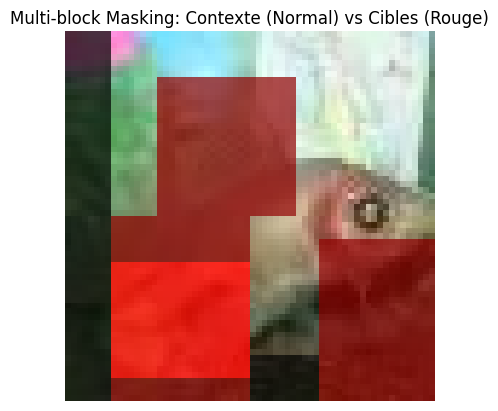

In [12]:
def visualize_masking(image, context_indices, target_indices_list, grid_size=16, patch_size=4):
    """
    Affiche le contexte et les cibles sur l'image.
    """
    img_np = image.permute(1, 2, 0).numpy()
    # On part d'une image assombrie pour faire ressortir le contexte
    vis_img = img_np.copy() * 0.3 
    
    # Révéler le contexte
    for idx in context_indices:
        r, c = idx // grid_size, idx % grid_size
        vis_img[r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size] = img_np[r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size]

    # Marquer les cibles en rouge (translucide)
    for target_indices in target_indices_list:
        for idx in target_indices:
            r, c = idx // grid_size, idx % grid_size
            vis_img[r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size, 0] += 0.4 # Ajouter du rouge
    
    plt.imshow(np.clip(vis_img, 0, 1))
    plt.title("Multi-block Masking: Contexte (Normal) vs Cibles (Rouge)")
    plt.axis('off')
    plt.show()

# Test sur une image du dataset
masker = MultiBlockMasker(grid_size=16) # 64/4 = 16
sample_img, _ = raw_dataset[0]
ctx_idx, tgt_idx_list = masker()

visualize_masking(sample_img, ctx_idx, tgt_idx_list)

## Entraînement

L'entraînement de I-JEPA est particulier car il ne compare pas des pixels, mais des vecteurs dans l'espace latent. 

1. **Moyenne Mobile Exponentielle (EMA)** : Les poids du *Target Encoder* sont une version lissée de ceux du *Context Encoder*. Cela stabilise les cibles et évite l'effondrement des représentations.
2. **Perte L2 Latente** : On calcule l'erreur quadratique moyenne entre les prédictions du *Predictor* et les représentations réelles produites par le *Target Encoder*.
3. **Scheduler de Momentum** : Le coefficient $\tau$ de l'EMA augmente généralement pendant l'entraînement (de 0.996 à 1.0) pour des cibles de plus en plus stables.

La fonction de coût est la distance quadratique moyenne ($L^2$) entre la représentation prédite et la représentation cible.

L'optimisation utilise typiquement AdamW avec un ordonnancement de taux d'apprentissage (Learning Rate) en cosinus. Il est aussi crucial d'inclure une phase de **Warmup** (montée en puissance progressive du LR depuis zéro) pour éviter que les gradients initiaux chaotiques ne détruisent l'architecture au tout début de l'entraînement.

In [13]:
class IJEPA(nn.Module):
    """
    Wrapper global coordonnant les encodeurs et le prédicteur.
    """
    def __init__(self, context_encoder, predictor):
        super().__init__()
        self.context_encoder = context_encoder
        self.predictor = predictor
        
        # Le Target Encoder est une copie initiale du Context Encoder
        self.target_encoder = copy.deepcopy(context_encoder)
        
        # On gèle le Target Encoder (pas de gradient)
        for p in self.target_encoder.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update_target_encoder(self, momentum):
        """
        Mise à jour EMA des poids : target = momentum * target + (1 - momentum) * context
        """
        for param_q, param_k in zip(self.context_encoder.parameters(), self.target_encoder.parameters()):
            param_k.data.mul_(momentum).add_((1 - momentum) * param_q.data)

    def forward(self, images, context_indices, target_indices_list):
        # 1. Obtenir les représentations cibles via le Target Encoder (sur l'image complète)
        with torch.no_grad():
            target_reps = self.target_encoder(images) # [B, N_patches, C]
            
        # 2. Obtenir les représentations du contexte via le Context Encoder (partiel)
        context_reps = self.context_encoder(images, patch_indices=context_indices) # [B, N_vis, C]
        
        # 3. Prédire chaque bloc cible
        preds = []
        targets = []
        
        for t_idx in target_indices_list:
            # t_idx: [B, N_target]
            # Prédiction via le Predictor
            p = self.predictor(context_reps, context_indices, t_idx) # [B, N_target, C]
            preds.append(p)
            
            # Extraction robuste via torch.gather pour éviter tout broadcasting [B, N_target, C]
            # On étend t_idx pour qu'il ait la même dimension que target_reps sur la dernière dimension
            expanded_idx = t_idx.unsqueeze(-1).expand(-1, -1, target_reps.size(-1))
            t = torch.gather(target_reps, 1, expanded_idx)
            targets.append(t)
            
        return preds, targets

### Fonction d'entraînement
Nous implémentons une boucle simplifiée. Dans un cadre réel, l'entraînement I-JEPA nécessite beaucoup d'époques, mais ici nous nous concentrons sur la validation de la méthodologie.

In [14]:
def train_one_epoch(model, dataloader, masker, optimizer, device, ema_momentum=0.996):
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc="Entraînement", leave=True)
    
    for images, _ in pbar:
        images = images.to(device)
        B = images.shape[0]
        
        ctx_idx, tgt_idx_list = masker()
        ctx_idx = ctx_idx.to(device).repeat(B, 1)
        tgt_idx_list = [t.to(device).repeat(B, 1) for t in tgt_idx_list]
        
        # Forward
        preds, targets = model(images, ctx_idx, tgt_idx_list)
        
        # Calcul de la perte
        loss = 0
        for p, t in zip(preds, targets):
            loss += F.mse_loss(p, t)
        loss /= len(preds)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        model.update_target_encoder(ema_momentum)
        
        total_loss += loss.item()
        
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        
    return total_loss / len(dataloader)


def save_checkpoint(model, optimizer, history, epoch, filename="ijepa_final_model.pth"):
    """
    Sauvegarde les états de tous les composants du modèle et de l'optimiseur.
    """
    checkpoint = {
        'epoch': epoch,
        'ctx': model.context_encoder.state_dict(),
        'tar': model.target_encoder.state_dict(),
        'pred': model.predictor.state_dict(),
        'optimizer': optimizer.state_dict(),
        'hist': history
    }
    torch.save(checkpoint, filename)
    print(f"Checkpoint sauvegardé à l'époque {epoch+1} : {filename}")

def load_checkpoint(model, optimizer, device, filename="ijepa_final_model.pth"):
    """
    Charge les états sauvegardés dans le modèle et l'optimiseur.
    """
    checkpoint = torch.load(filename, map_location=device)
    model.context_encoder.load_state_dict(checkpoint['ctx'])
    model.target_encoder.load_state_dict(checkpoint['tar'])
    model.predictor.load_state_dict(checkpoint['pred'])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer'])
    print(f"Checkpoint chargé : {filename} (Reprise à l'époque {checkpoint['epoch']+1})")
    return checkpoint['hist'], checkpoint['epoch']

On ajoute des fonctions permettant de sauvegarder et charger les poids sous forme de checkpoint ce qui permet de reprendre l'entrainement à une époque donnée ce qui est crucial car on a ici pas assez de mémoire pour faire tout l'entrainement en une seule fois.

In [15]:
def train_ijepa(model, dataloader, masker, optimizer, device, num_epochs=10, ema_momentum=0.996, start_epoch=0, history=None):
    """
    Boucle d'entraînement complète avec sauvegarde à chaque époque.
    """
    if history is None: history = []
    print(f"Début de l'entraînement de l'époque {start_epoch+1} à {num_epochs}...")
    
    for epoch in range(start_epoch, num_epochs):
        loss = train_one_epoch(model, dataloader, masker, optimizer, device, ema_momentum)
        history.append(loss)
        print(f"Époque [{epoch+1}/{num_epochs}] - Perte L2 : {loss:.6f}")
        
        # Sauvegarde à chaque époque pour permettre la reprise après crash/redémarrage
        save_checkpoint(model, optimizer, history, epoch, filename=f"ijepa_epoch_{epoch+1}.pth")
        save_checkpoint(model, optimizer, history, epoch, filename="ijepa_latest.pth")
        
    # Visualisation de la courbe d'apprentissage
    plt.figure(figsize=(10, 5))
    plt.plot(history)
    plt.title("Évolution de la perte L2 (I-JEPA)")
    plt.xlabel("Époque")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.savefig("ijepa_loss_curve.png")
    plt.show()
    
    return history

In [16]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Utilisation du device : {device}")

Utilisation du device : cuda


### Entraînement

In [17]:
# entraînement sur 5 premières époques
v_ctx = VisionTransformer(depth=12).to(device)
v_pred = IJEPAPredictor().to(device)
ijepa_model = IJEPA(v_ctx, v_pred).to(device)
optimizer = torch.optim.AdamW(ijepa_model.parameters(), lr=1e-4)

print(f"Modèle prêt sur {device}")

Modèle prêt sur cuda


Début de l'entraînement de l'époque 1 à 5...
Époque [1/5] - Perte L2 : 0.140231
Checkpoint sauvegardé à l'époque 1 : ijepa_epoch_1.pth
Checkpoint sauvegardé à l'époque 1 : ijepa_latest.pth
Époque [2/5] - Perte L2 : 0.074469
Checkpoint sauvegardé à l'époque 2 : ijepa_epoch_2.pth
Checkpoint sauvegardé à l'époque 2 : ijepa_latest.pth
Époque [3/5] - Perte L2 : 0.101848
Checkpoint sauvegardé à l'époque 3 : ijepa_epoch_3.pth
Checkpoint sauvegardé à l'époque 3 : ijepa_latest.pth
Époque [4/5] - Perte L2 : 0.144287
Checkpoint sauvegardé à l'époque 4 : ijepa_epoch_4.pth
Checkpoint sauvegardé à l'époque 4 : ijepa_latest.pth
Époque [5/5] - Perte L2 : 0.189014
Checkpoint sauvegardé à l'époque 5 : ijepa_epoch_5.pth
Checkpoint sauvegardé à l'époque 5 : ijepa_latest.pth


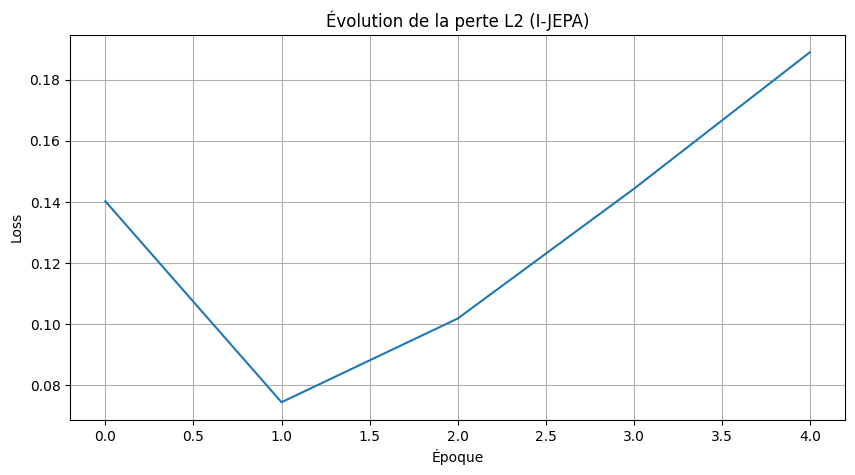

In [18]:
num_epochs = 5
history = train_ijepa(ijepa_model, train_loader, masker, optimizer, device, num_epochs=num_epochs)

Entrainement pour 15 époques supplémentaires en faisant 5 par 5 (on est obligé de faire l'entrainement petit à petit en raison de la mémoire que nécessite l'entraînement).

Checkpoint chargé : ijepa_latest.pth (Reprise à l'époque 15)
Début de l'entraînement de l'époque 15 à 19...


Entraînement: 100%|██████████| 1563/1563 [04:18<00:00,  6.04it/s, loss=0.4181]


Époque [15/19] - Perte L2 : 0.380228
Checkpoint sauvegardé à l'époque 15 : ijepa_epoch_15.pth
Checkpoint sauvegardé à l'époque 15 : ijepa_latest.pth


Entraînement: 100%|██████████| 1563/1563 [04:34<00:00,  5.70it/s, loss=0.3216]


Époque [16/19] - Perte L2 : 0.376654
Checkpoint sauvegardé à l'époque 16 : ijepa_epoch_16.pth
Checkpoint sauvegardé à l'époque 16 : ijepa_latest.pth


...

Époque [17/19] - Perte L2 : 0.379723
Checkpoint sauvegardé à l'époque 17 : ijepa_epoch_17.pth
Checkpoint sauvegardé à l'époque 17 : ijepa_latest.pth


Entraînement: 100%|██████████| 1563/1563 [16:54<00:00,  1.54it/s, loss=0.4571]  


Époque [18/19] - Perte L2 : 0.382710
Checkpoint sauvegardé à l'époque 18 : ijepa_epoch_18.pth
Checkpoint sauvegardé à l'époque 18 : ijepa_latest.pth


Entraînement: 100%|██████████| 1563/1563 [10:58<00:00,  2.37it/s, loss=0.3781]


Époque [19/19] - Perte L2 : 0.378336
Checkpoint sauvegardé à l'époque 19 : ijepa_epoch_19.pth
Checkpoint sauvegardé à l'époque 19 : ijepa_latest.pth


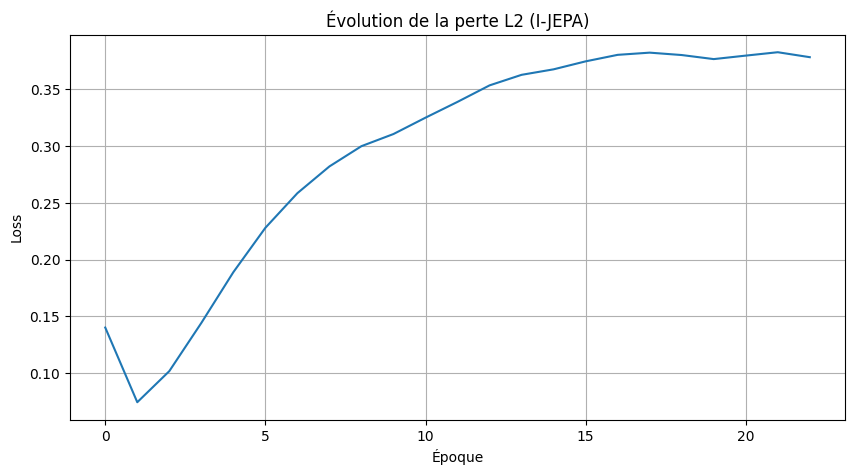

In [21]:
num_epochs = 5
for i in range(3):
    del ijepa_model, v_ctx, v_pred, optimizer
    torch.cuda.empty_cache()

    v_ctx = VisionTransformer(depth=12).to(device)
    v_pred = IJEPAPredictor().to(device)
    ijepa_model = IJEPA(v_ctx, v_pred).to(device)
    optimizer = torch.optim.AdamW(ijepa_model.parameters(), lr=1e-4)

    history, start_epoch = load_checkpoint(ijepa_model, optimizer, device, filename="ijepa_latest.pth")
    history = train_ijepa(ijepa_model, train_loader, masker, optimizer, device, num_epochs=start_epoch+num_epochs, start_epoch=start_epoch, history=history)

Au total, l'entrainement pour 20 époques a pris 2h43min sur RTX4070Ti.

On obtient finalement un modèle donc la convergence semble se stabiliser sur ces quelques époques, pour autant la loss augmente au fil de l'entrainement.

Du fait de l'entrainement de ViT (qui contiennes différentes attentions donc matrices lourdes), l'entrainement nécessite beaucoup de RAM ou VRAM, ici les 12Go de VRAM de notre GPU sont utilisés.

## Validation

I-JEPA ne produisant pas de pixels, nous utilisons deux méthodes pour valider l'apprentissage :
1. **Linear Probing** : On gèle l'encodeur et on entraîne une couche linéaire pour la classification. Si la précision est bonne, c'est que les vecteurs latents contiennent de la sémantique.
2. **Pixel Reconstruction** : On entraîne un décodeur très léger pour transformer les vecteurs latents en images 64x64. Cela permet de visualiser ce que le modèle "voit".

### 1. Décodeur Léger pour Visualisation
Nous utilisons un petit réseau de déconvolution pour transformer les embeddings (192 dim) en pixels (3 chans).

In [90]:
class LightPixelDecoder(nn.Module):
    """
    Petit décodeur pour transformer les représentations latentes en pixels.
    """
    def __init__(self, embed_dim=192, p=4, grid=16):
        super().__init__()
        self.p = p
        self.grid = grid
        
        # Projection pour retrouver l'espace des pixels du patch
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Linear(512, p * p * 3)
        )

    def forward(self, x):
        # x: [B, N_patches, Embed_dim]
        B = x.shape[0]
        x = self.decoder(x).reshape(B, self.grid, self.grid, self.p, self.p, 3)
        
        # Reconstruction de l'image par assemblage des patchs
        return x.permute(0, 5, 1, 3, 2, 4).reshape(B, 3, self.grid * self.p, self.grid * self.p)

### 2. Linear Probe pour Classification
C'est le standard pour évaluer les représentations auto-supervisées.

In [91]:
class LinearProbe(nn.Module):
    def __init__(self, embed_dim=192, num_classes=200):
        super().__init__()
        self.linear = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # On prend la moyenne des embeddings de tous les patchs (Global Average Pooling)
        x = x.mean(dim=1)
        return self.linear(x)

### Entrainement des modèles de validation

In [92]:
def train_evaluation_tools(model, train_loader, device, epochs=5):

    probe, decoder = LinearProbe().to(device), LightPixelDecoder().to(device)
    opt_p, opt_d = torch.optim.AdamW(probe.parameters(), lr=1e-3), torch.optim.AdamW(decoder.parameters(), lr=1e-3)

    model.eval()

    print("Entraînement des outils d'évaluation...")

    for epoch in range(epochs):
        # On définit la description de la barre avec l'époque actuelle
        pbar = tqdm(train_loader, desc=f"Époque {epoch+1}/{epochs}", leave=True)
        
        p_loss_acc, d_loss_acc = 0, 0

        # On boucle sur pbar au lieu de train_loader
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            # CORRECTIF : Seul le modèle figé est sous torch.no_grad()
            with torch.no_grad(): 
                reps = model.context_encoder(images)
            
            # --- Entraînement de la Probe ---
            loss_p = F.cross_entropy(probe(reps), labels)
            opt_p.zero_grad()
            loss_p.backward()
            opt_p.step()

            # --- Entraînement du Décodeur ---
            loss_d = F.mse_loss(decoder(reps), images)
            opt_d.zero_grad()
            loss_d.backward()
            opt_d.step()
            
            p_loss_acc += loss_p.item()
            d_loss_acc += loss_d.item()
            
            # Mise à jour des métriques affichées en direct sur la barre
            pbar.set_postfix(probe_loss=f"{loss_p.item():.4f}", dec_loss=f"{loss_d.item():.4f}")

        # Affichage du résumé en fin d'époque
        print(f"-> [Fin Époque {epoch+1}] Probe Loss Moyenne: {p_loss_acc/len(train_loader):.4f} | Decoder Loss Moyenne: {d_loss_acc/len(train_loader):.4f}\n")
        
    return probe, decoder

In [93]:
def denormalize(tensor):
    """
    Inverse la normalisation ImageNet pour la visualisation.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    return (tensor * std + mean).clip(0, 1)

In [94]:
def final_viz(model, decoder, masker, dataset, device, target_classes, num_samples=10):
    model.eval(); decoder.eval()
    # Filtrer les indices du dataset appartenant aux classes cibles
    eligible_indices = [i for i, l in enumerate(dataset.labels) if l in target_classes]
    selected_indices = np.random.choice(eligible_indices, num_samples, replace=False)
    
    n_cols_pairs = 5
    n_rows = (num_samples + n_cols_pairs - 1) // n_cols_pairs
    fig, axes = plt.subplots(n_rows, n_cols_pairs * 2, figsize=(20, 4 * n_rows))
    axes_flat = axes.flatten() if n_rows > 1 else axes
    
    for i, idx in enumerate(selected_indices):
        img, label = dataset[idx]; img_t = img.unsqueeze(0).to(device)
        ctx_idx, tgt_list = masker()
        with torch.no_grad():
            ctx_idx_b = ctx_idx.unsqueeze(0).to(device)
            tgt_list_b = [t.unsqueeze(0).to(device) for t in tgt_list]
            context_reps = model.context_encoder(img_t, patch_indices=ctx_idx_b)
            preds, _ = model(img_t, ctx_idx_b, tgt_list_b)
            hybrid = torch.zeros(1, 256, 192).to(device)
            hybrid[0, ctx_idx] = context_reps[0]
            for j, t in enumerate(tgt_list): hybrid[0, t] = preds[j][0]
            res_rgb = denormalize(decoder(hybrid)[0]).cpu().permute(1,2,0).numpy()
            orig_rgb = denormalize(img).cpu().permute(1,2,0).numpy()
        
        ax_orig = axes_flat[i * 2]
        ax_orig.imshow(orig_rgb); ax_orig.set_title(f"Class {label}", fontsize=8); ax_orig.axis('off')
        ax_res = axes_flat[i * 2 + 1]
        ax_res.imshow(res_rgb); ax_res.set_title("IA Rec", fontsize=8); ax_res.axis('off')
        
        grid_size, patch_size = 16, 4
        target_mask = np.zeros((grid_size, grid_size))
        for t in tgt_list:
            target_mask[t.cpu().numpy() // grid_size, t.cpu().numpy() % grid_size] = 1
        target_mask_full = target_mask.repeat(patch_size, axis=0).repeat(patch_size, axis=1)
        ax_res.contour(target_mask_full, levels=[0.5], colors='lime', linewidths=1.5, alpha=0.9)
    
    plt.tight_layout(); plt.show()

In [95]:
del ijepa_model, v_ctx, v_pred, optimizer
torch.cuda.empty_cache()

In [96]:
v_ctx = VisionTransformer(depth=12).to(device)
v_pred = IJEPAPredictor().to(device)
ijepa_model = IJEPA(v_ctx, v_pred).to(device)
optimizer = torch.optim.AdamW(ijepa_model.parameters(), lr=1e-4)

load_checkpoint(ijepa_model, optimizer, device, filename="ijepa_latest.pth")

# Entraînement du Probe et du Décodeur (sur l'encodeur de contexte gelé)
# On utilise généralement peu d'époques car les caractéristiques sont déjà là.
probe, decoder = train_evaluation_tools(ijepa_model, train_loader, device, epochs=5)

Checkpoint chargé : ijepa_latest.pth (Reprise à l'époque 19)
Entraînement des outils d'évaluation...


Époque 1/5: 100%|██████████| 1563/1563 [01:02<00:00, 24.89it/s, dec_loss=0.0545, probe_loss=3.9642]


-> [Fin Époque 1] Probe Loss Moyenne: 4.5059 | Decoder Loss Moyenne: 0.0934



Époque 2/5: 100%|██████████| 1563/1563 [01:03<00:00, 24.53it/s, dec_loss=0.0475, probe_loss=3.8996]


-> [Fin Époque 2] Probe Loss Moyenne: 4.0509 | Decoder Loss Moyenne: 0.0554



...

-> [Fin Époque 3] Probe Loss Moyenne: 3.9418 | Decoder Loss Moyenne: 0.0504



Époque 4/5: 100%|██████████| 1563/1563 [01:02<00:00, 25.03it/s, dec_loss=0.0467, probe_loss=4.2566]


-> [Fin Époque 4] Probe Loss Moyenne: 3.8907 | Decoder Loss Moyenne: 0.0480



Époque 5/5: 100%|██████████| 1563/1563 [01:02<00:00, 25.17it/s, dec_loss=0.0510, probe_loss=3.6005]

-> [Fin Époque 5] Probe Loss Moyenne: 3.8550 | Decoder Loss Moyenne: 0.0467



### Visualisation de la représentation faite du modèle

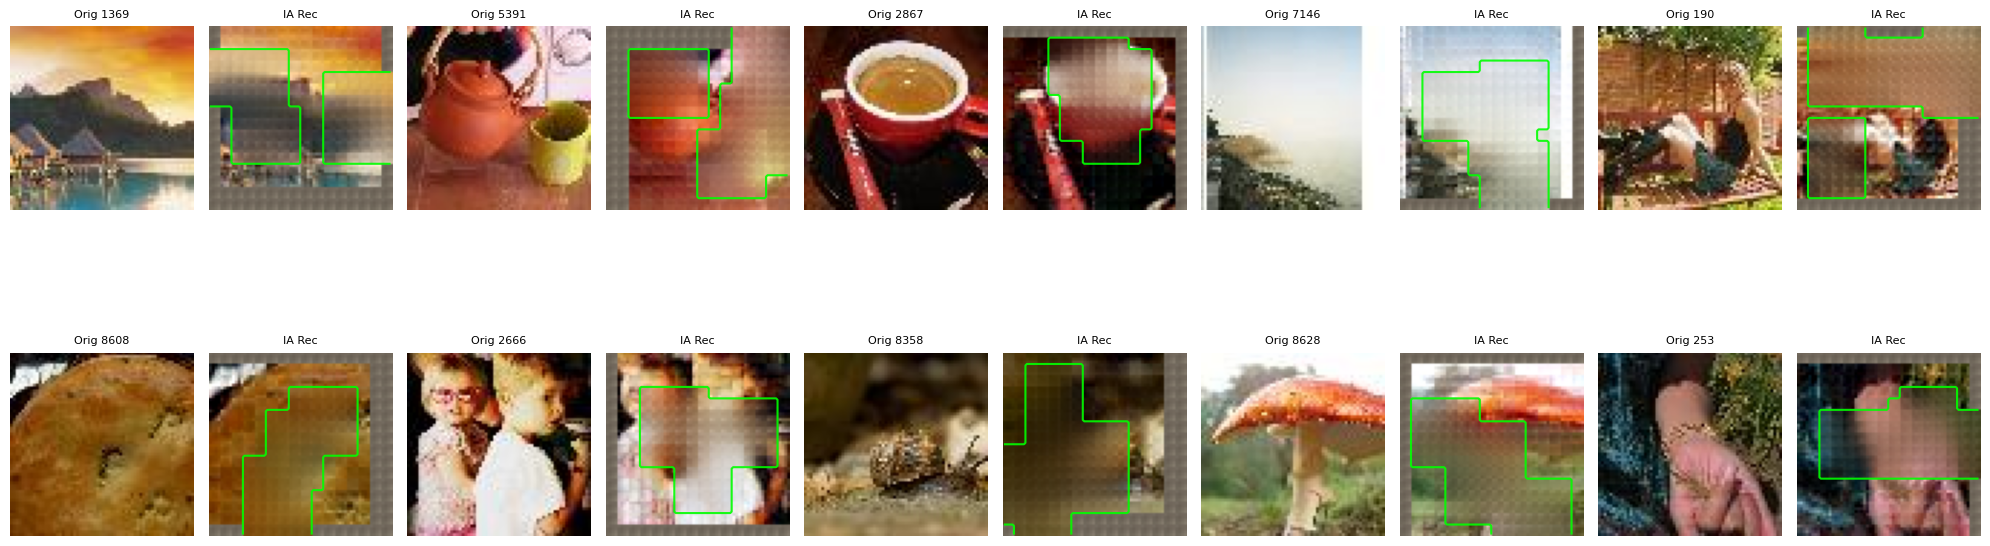

In [77]:
final_viz(ijepa_model, decoder, masker, val_dataset, device, num_samples=10)

Le modèle ajoute beaucoup de flou, ce n'est pas le cas dans l'article mais c'est du à notre méthodologie de reproduction qui a réduit la taille des patch et qui utilise des images de plus faible résolution en entrée des ViT.

### Classification à partir de l'espace latent du I-JEPA

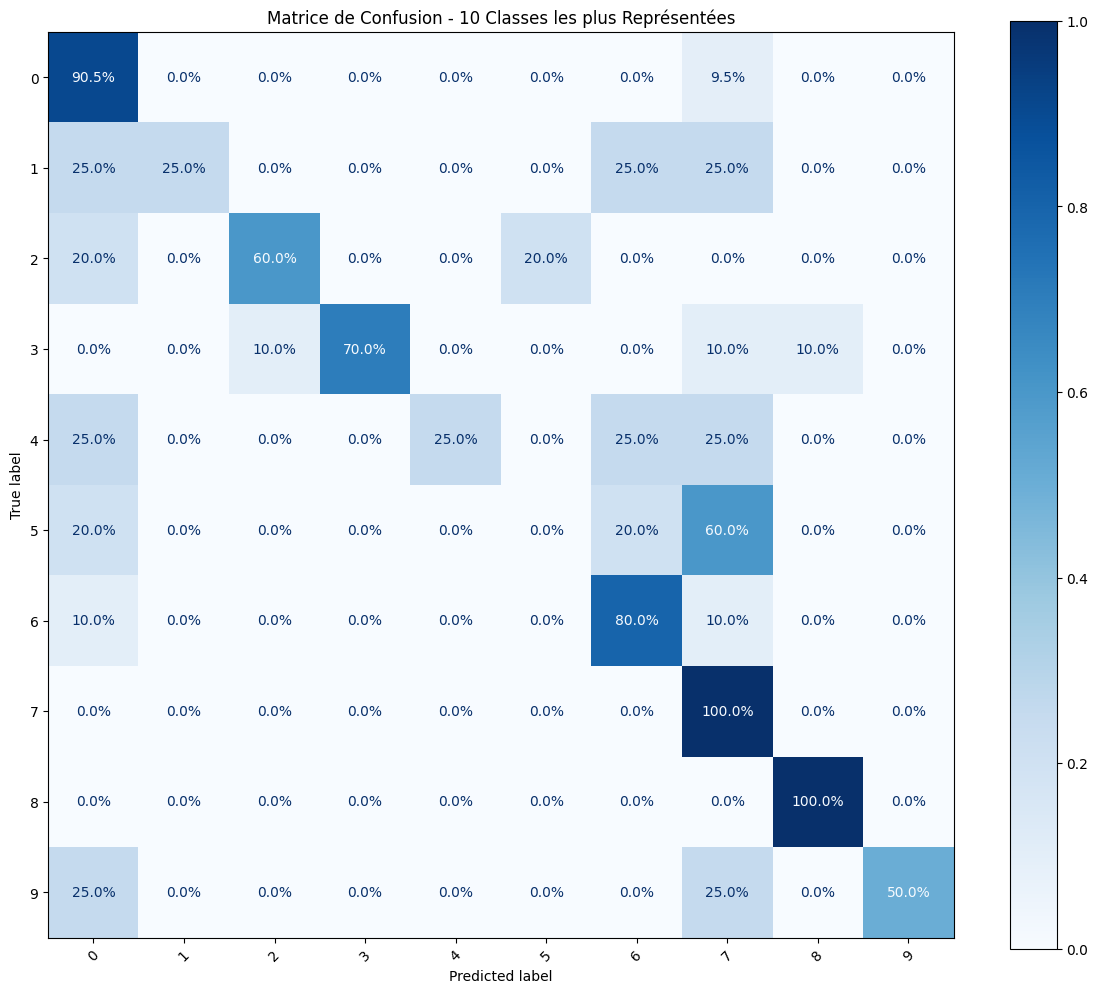

In [97]:
def evaluate_accuracy(model, probe, dataloader, device, target_classes):
    model.eval(); probe.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            # Filtrer pour ne garder que les classes cibles
            mask = torch.tensor([l.item() in target_classes for l in labels])
            if not mask.any(): continue
            
            reps = model.context_encoder(imgs[mask].to(device))
            preds = torch.argmax(probe(reps), dim=1)
            all_preds.extend(preds.cpu().numpy()); all_labels.extend(labels[mask].numpy())
    
    class_map = {old_id: new_id for new_id, old_id in enumerate(target_classes)}
    mapped_true = [class_map[l] for l in all_labels]
    mapped_preds = [class_map.get(p, -1) for p in all_preds]
    
    return np.array(mapped_true), np.array(mapped_preds), target_classes


def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=range(10), normalize='true')

    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='.1%', ax=plt.gca(), xticks_rotation=45)

    plt.title(f"Matrice de Confusion - 10 Classes les plus Représentées")
    plt.tight_layout()
    plt.show()

eval_labels, eval_preds, _ = evaluate_accuracy(ijepa_model, probe, val_loader, device, top_10_classes)
plot_confusion_matrix(eval_labels, eval_preds)

Sur les 10 classes, les résultats sont plutot bons même si le modèle n'arrive pas du tout à reconnaitre certaines classes.

On a parfois 100% car il y a peu d'images dans le jeu de validation.

## Conclusion

On peut via notre implémentation valider le fonctionnement de la méthodologie des scientifiques dans l'article ainsi que celui des modèles mais on ne peut pas valider ou exploiter les résultats en raison de notre puissance de calcul très limitée.